In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
mall = pd.read_csv("Mall_Customers - Mall_Customers.csv")
mall

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,15,Male,37,$20,13
2,2,Male,21,15,81
3,3,Female,20,16,6
4,4,Female,23,16,77
...,...,...,...,...,...
197,196,Female,35,120,79
198,197,Female,45,126,28
199,198,Male,32,126,74
200,199,Male,32,137,18


In [2]:
mall.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,15,Male,37,$20,13
2,2,Male,21,15,81
3,3,Female,20,16,6
4,4,Female,23,16,77


In [3]:
mall.head(20)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,15,Male,37,$20,13
2,2,Male,21,15,81
3,3,Female,20,16,6
4,4,Female,23,16,77
5,5,Female,31,17,40
6,6,Female,22,17,76
7,7,Female,35,18,6
8,8,Female,23,18,94
9,9,Male,64,19,3


In [4]:
mall.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
197,196,Female,35,120,79
198,197,Female,45,126,28
199,198,Male,32,126,74
200,199,Male,32,137,18
201,200,Male,30,137,83


In [5]:
mall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              202 non-null    int64 
 1   Gender                  202 non-null    object
 2   Age                     202 non-null    int64 
 3   Annual Income (k$)      202 non-null    object
 4   Spending Score (1-100)  202 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 8.0+ KB


In [6]:
mall.rename(columns={'Annual Income (k$)':'Annual_Income','Spending Score (1-100)':'Spending_Score'},inplace=True)
mall

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,15,Male,37,$20,13
2,2,Male,21,15,81
3,3,Female,20,16,6
4,4,Female,23,16,77
...,...,...,...,...,...
197,196,Female,35,120,79
198,197,Female,45,126,28
199,198,Male,32,126,74
200,199,Male,32,137,18


In [7]:
mall[['Age','Spending_Score']].describe()

,Age,Spending_Score
count,202.000000,202.000000
mean,38.663366,50.297030
std,14.025050,25.798316
min,18.000000,1.000000
25%,28.000000,35.000000
50%,36.000000,50.000000
75%,49.000000,73.000000
max,70.000000,99.000000


In [8]:
mall = mall.drop("CustomerID",axis = 1)
mall

,Gender,Age,Annual_Income,Spending_Score
0,Male,19,15,39
1,Male,37,$20,13
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
...,...,...,...,...
197,Female,35,120,79
198,Female,45,126,28
199,Male,32,126,74
200,Male,32,137,18


In [9]:
mall['Annual_Income'].unique()

array(['15', '$20', '16', '17', '18', '19', '20', '21', '23', '24', '$24',
       '25', '28', '29', '30', '33', '34', '37', '38', '39', '40', '42',
       '43', '44', '46', '47', '48', '49', '50', '54', '57', '58', '59',
       '60', '61', '62', '63', '64', '65', '67', '69', '70', '71', '72',
       '73', '74', '75', '76', '77', '78', '79', '81', '85', '86', '87',
       '88', '93', '97', '98', '99', '101', '103', '113', '120', '126',
       '137'], dtype=object)

In [10]:
mall["Annual_Income"] = mall["Annual_Income"].str.replace("$","")
mall

,Gender,Age,Annual_Income,Spending_Score
0,Male,19,15,39
1,Male,37,20,13
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
...,...,...,...,...
197,Female,35,120,79
198,Female,45,126,28
199,Male,32,126,74
200,Male,32,137,18


In [11]:
mall["Annual_Income"] = pd.to_numeric(mall["Annual_Income"],errors="coerce")
mall.dtypes

Gender            object
Age                int64
Annual_Income      int64
Spending_Score     int64
dtype: object

In [12]:
mall[['Age','Annual_Income','Spending_Score']].describe()

,Age,Annual_Income,Spending_Score
count,202.000000,202.000000,202.000000
mean,38.663366,60.108911,50.297030
std,14.025050,26.522084,25.798316
min,18.000000,15.000000,1.000000
25%,28.000000,40.000000,35.000000
50%,36.000000,61.000000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [13]:
mall.isnull().sum()

Gender            0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64

In [14]:
mall[['Age','Spending_Score']].mean()
mall[['Age','Spending_Score']].std()

Age               14.025050
Spending_Score    25.798316
dtype: float64

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11184\3733044217.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(males_age, bins=age_bins, kde=False, color='#0066ff', ax=ax1, hist_kws=dict(edgecolor="k", linewidth=2))
C:\Users\ASUS\AppData\Local\Temp\ipykernel_11184\3733044217.py:17: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed297445

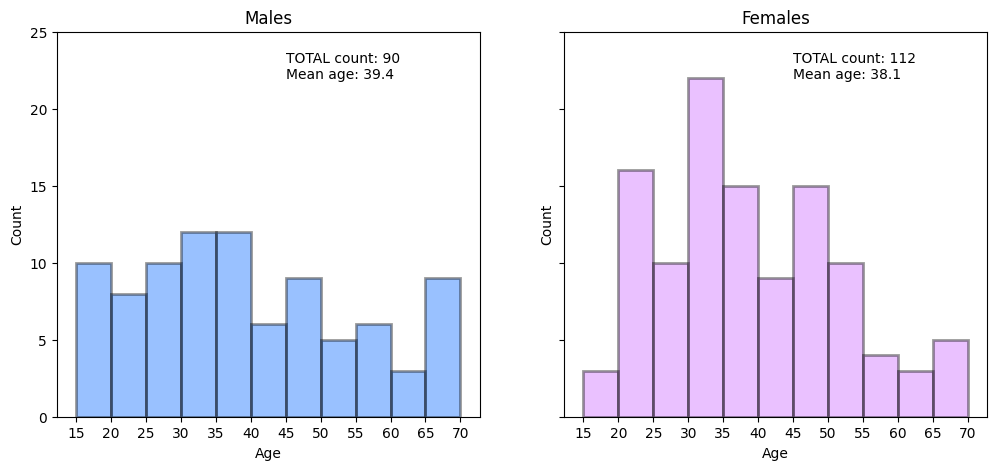

In [15]:
males_age = mall[mall['Gender']=='Male']['Age'] # subset with males age
females_age = mall[mall['Gender']=='Female']['Age'] # subset with females age

age_bins = range(15,75,5)

# males histogram
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5), sharey=True)
sns.distplot(males_age, bins=age_bins, kde=False, color='#0066ff', ax=ax1, hist_kws=dict(edgecolor="k", linewidth=2))
ax1.set_xticks(age_bins)
ax1.set_ylim(top=25)
ax1.set_title('Males')
ax1.set_ylabel('Count')
ax1.text(45,23, "TOTAL count: {}".format(males_age.count()))
ax1.text(45,22, "Mean age: {:.1f}".format(males_age.mean()))

# females histogram
sns.distplot(females_age, bins=age_bins, kde=False, color='#cc66ff', ax=ax2, hist_kws=dict(edgecolor="k", linewidth=2))
ax2.set_xticks(age_bins)
ax2.set_title('Females')
ax2.set_ylabel('Count')
ax2.text(45,23, "TOTAL count: {}".format(females_age.count()))
ax2.text(45,22, "Mean age: {:.1f}".format(females_age.mean()))

plt.show()

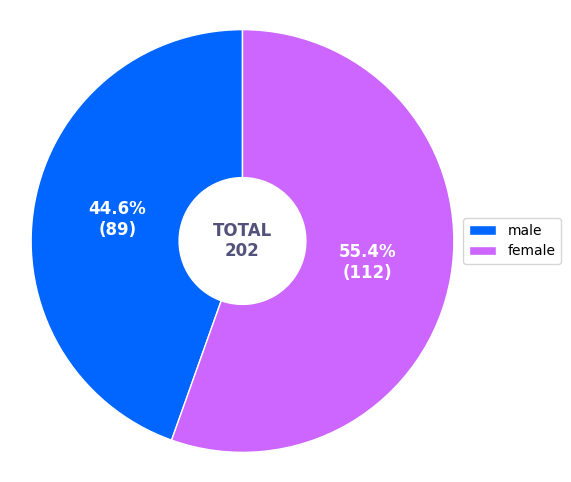

In [16]:
def labeler(pct, allvals):
    absolute = int(pct/100.*np.sum(allvals))
    return "{:.1f}%\n({:d})".format(pct, absolute)

sizes = [males_age.count(),females_age.count()] # wedge sizes

fig0, ax1 = plt.subplots(figsize=(6,6))
wedges, texts, autotexts = ax1.pie(sizes,
                                   autopct=lambda pct: labeler(pct, sizes),
                                   radius=1,
                                   colors=['#0066ff','#cc66ff'],
                                   startangle=90,
                                   textprops=dict(color="w"),
                                   wedgeprops=dict(width=0.7, edgecolor='w'))

ax1.legend(wedges, ['male','female'],
           loc='center right',
           bbox_to_anchor=(0.7, 0, 0.5, 1))

plt.text(0,0, 'TOTAL\n{}'.format(mall['Age'].count()),
         weight='bold', size=12, color='#52527a',
         ha='center', va='center')

plt.setp(autotexts, size=12, weight='bold')
ax1.axis('equal')  # Equal aspect ratio
plt.show()

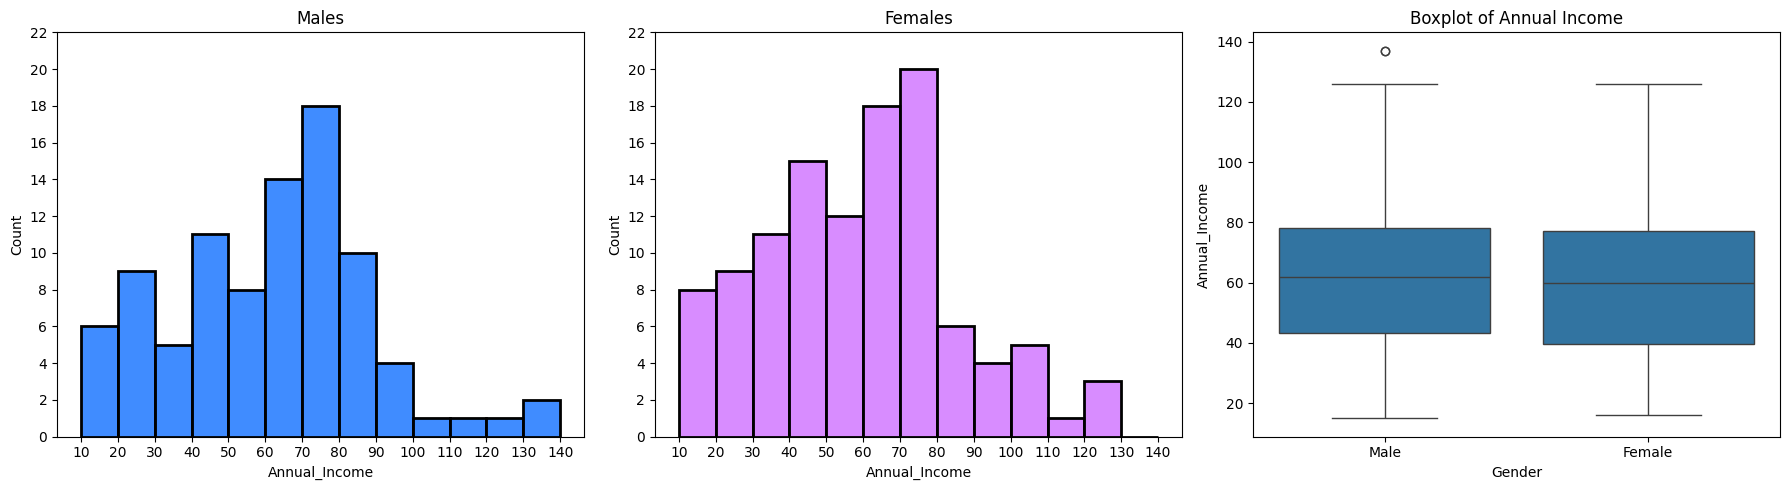

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'mall' DataFrame is already defined
males_income = mall[mall['Gender'] == 'Male']['Annual_Income']  # subset with males income
females_income = mall[mall['Gender'] == 'Female']['Annual_Income']  # subset with females income

my_bins = range(10, 150, 10)

# Create subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Males histogram
sns.histplot(males_income, bins=my_bins, color='#0066ff', ax=ax1, edgecolor="k", linewidth=2)
ax1.set_xticks(my_bins)
ax1.set_yticks(range(0, 24, 2))
ax1.set_ylim(0, 22)
ax1.set_title('Males')
ax1.set_ylabel('Count')

# Females histogram
sns.histplot(females_income, bins=my_bins, color='#cc66ff', ax=ax2, edgecolor="k", linewidth=2)
ax2.set_xticks(my_bins)
ax2.set_yticks(range(0, 24, 2))
ax2.set_ylim(0, 22)
ax2.set_title('Females')
ax2.set_ylabel('Count')

# Boxplot
sns.boxplot(x='Gender', y='Annual_Income', data=mall, ax=ax3)  # Ensure the column name matches
ax3.set_title('Boxplot of Annual Income')

# Show the plots
plt.tight_layout()
plt.show()

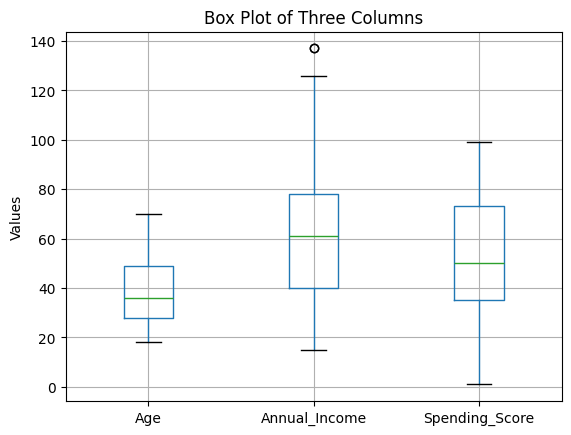

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
mall.boxplot(column=["Age","Annual_Income","Spending_Score"])
plt.ylabel("Values")
plt.title("Box Plot of Three Columns")
plt.show()

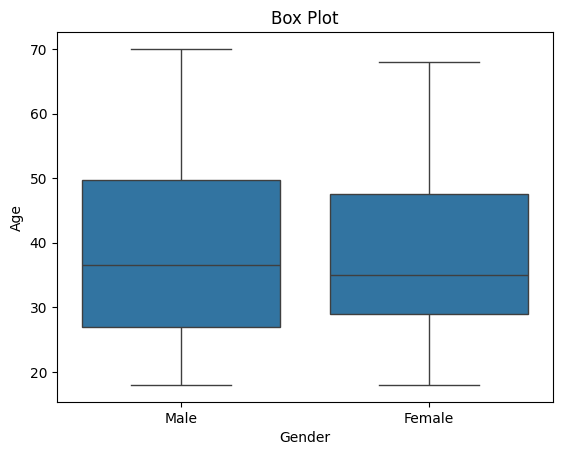

In [19]:
sns.boxplot(x = "Gender",y = "Age", data = mall)
plt.title("Box Plot")
plt.show()

In [20]:
import plotly.express as pt
pt.box(mall,x ="Gender",y ="Annual_Income",color ="Gender")

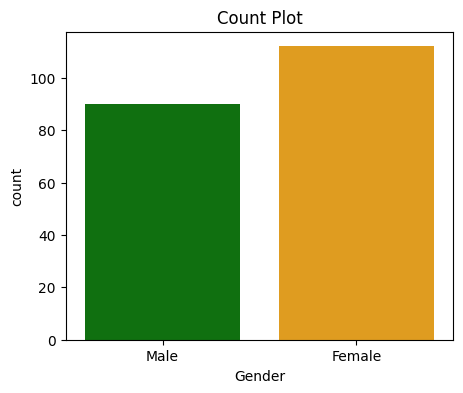

In [21]:
plt.figure(figsize=(5,4))
sns.countplot(x="Gender",data=mall,hue="Gender",palette=["Green","Orange"])
plt.title("Count Plot")
plt.show()

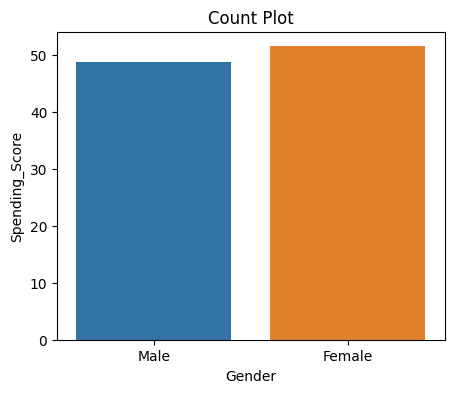

In [22]:
plt.figure(figsize=(5,4))
sns.barplot(x="Gender",y="Spending_Score",data=mall,hue="Gender",errorbar=None)
plt.title("Count Plot")
plt.show()

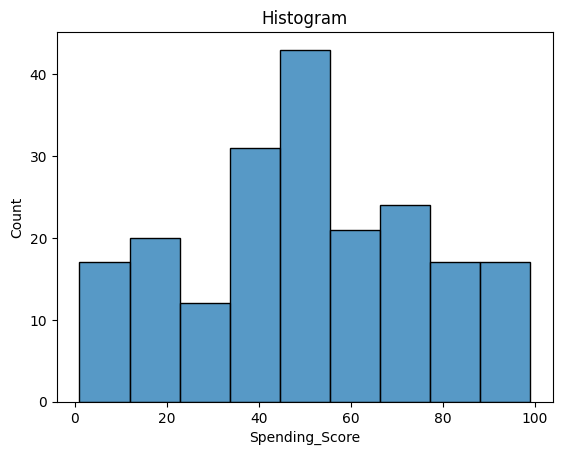

In [23]:
sns.histplot(data=mall,x="Spending_Score")
plt.title("Histogram")
plt.show()

In [24]:
pt.histogram(mall,x ="Annual_Income",nbins=25,title="Histogram Plotly")

In [25]:
import numpy as np
Q1 = mall["Annual_Income"].quantile(0.25)
Q3 = mall["Annual_Income"].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR

print(f"lower_bound : {lower_bound}")
print(f"upper_bound : {upper_bound}")

median_value = mall["Annual_Income"].median() # median calculate
print(f"median_value : {median_value}")

mall["Annual_Income"] = np.where((mall["Annual_Income"]<lower_bound)|(mall["Annual_Income"]>upper_bound),median_value,mall["Annual_Income"])
print("Data after replacing outliers with median :\n",mall)

lower_bound : -17.0
upper_bound : 135.0
median_value : 61.0
Data after replacing outliers with median :
      Gender  Age  Annual_Income  Spending_Score
0      Male   19           15.0              39
1      Male   37           20.0              13
2      Male   21           15.0              81
3    Female   20           16.0               6
4    Female   23           16.0              77
..      ...  ...            ...             ...
197  Female   35          120.0              79
198  Female   45          126.0              28
199    Male   32          126.0              74
200    Male   32           61.0              18
201    Male   30           61.0              83

[202 rows x 4 columns]


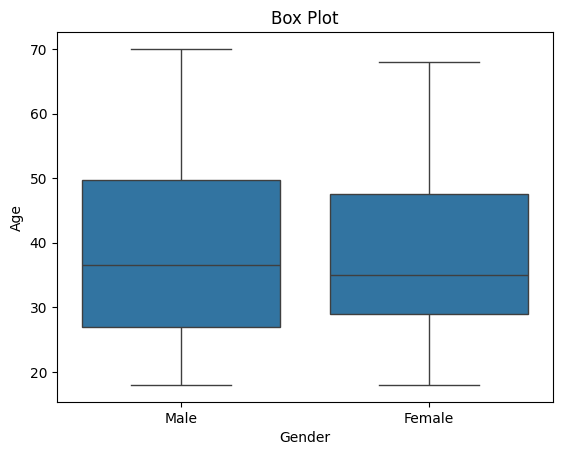

In [26]:
sns.boxplot(x = "Gender",y = "Age", data = mall)
plt.title("Box Plot")
plt.show()

In [27]:
import plotly.express as pt
fig = pt.pie(data_frame=mall,names="Gender")
fig.show()

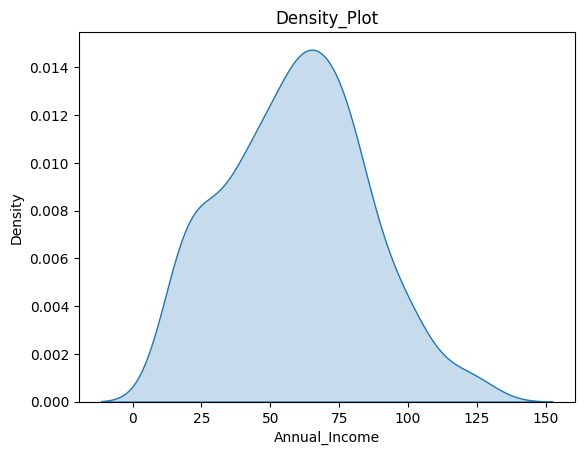

In [28]:
sns.kdeplot(data=mall["Annual_Income"],fill=True)
plt.title("Density_Plot")
plt.show()

In [ ]:
sns.kdeplot(data=mall["Spending_ource"])
plt.title("Density_Plot")
plt.show()

KeyError: 'Spending_source'

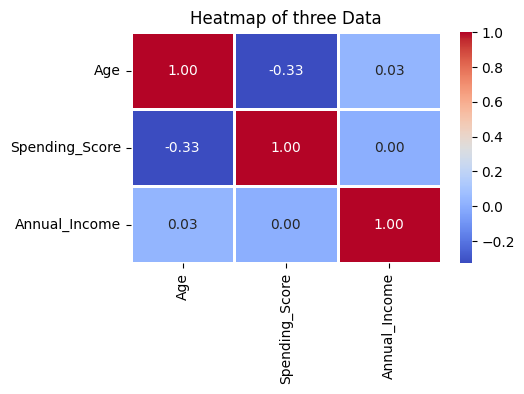

In [ ]:
heat_map = ["Age","Spending_Score","Annual_Income"]
heat_map_1 = mall[heat_map]
correlation_matrix = heat_map_1.corr()
plt.figure(figsize=(5,3))
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm",linewidth=2,fmt=".2f")
plt.title("Heatmap of three Data")
plt.show()

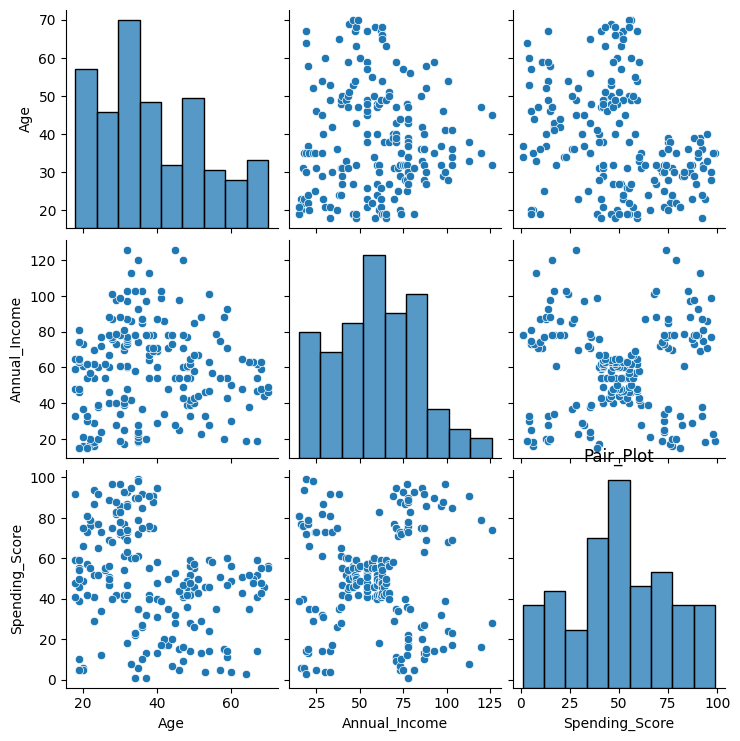

In [ ]:
sns.pairplot(mall)
plt.title("Pair_Plot")
plt.show()